In [60]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import pyreadstat
from pathlib import Path
import matplotlib.pyplot as plt

In [27]:
data_path = Path(r"C:\dev\projects\BSU_DA\Annual 2005-2011_START.sav")
data, _ = pyreadstat.read_sav(data_path)

In [31]:
data.head()

,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,...,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
0,6095.0,0.942380,0.060563,0.678302,-0.161531,NaN,0.202055,0.165019,0.399033,0.799019,...,1.082798,0.655937,4.454819,3.975687,0.892446,1007.536232,0.076738,0.055049,0.034904,5.0
1,255.0,1.980494,0.274382,0.916775,0.624425,NaN,0.089377,0.220648,0.000000,0.933519,...,1.123828,0.705951,10.618881,12.295547,1.157895,357.294118,0.116068,0.059740,0.025647,5.0
2,114.0,0.374160,0.001494,0.085138,-1.504990,NaN,0.235739,0.508929,0.888889,0.779049,...,1.185374,0.123415,0.794785,6.258929,7.875000,36.894737,-0.584879,0.010563,0.000000,5.0
3,365.0,7.859079,0.831978,2.449864,0.875862,NaN,0.059439,0.030030,0.011111,0.942010,...,1.309449,2.804607,48.363889,26.142643,0.540541,33.676983,0.171731,0.496295,0.312415,5.0
4,168.0,1.779376,0.005596,0.883293,0.527853,NaN,0.135491,0.886686,0.489796,0.887341,...,0.994832,0.473041,5.628827,3.125354,0.555241,19.103896,0.064809,0.025726,0.011839,5.0


In [29]:
data.columns

Index(['Cреднеспис.числ.работн', 'k1', 'k2', 'k3', 'k4', 'k4_new', 'k5', 'k6',
       'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13', 'k14', 'k15', 'k16',
       'k17', 'k18', 'k19', 'k20', 'Year'],
      dtype='object')

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2695 entries, 0 to 2694
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Cреднеспис.числ.работн  2695 non-null   float64
 1   k1                      2695 non-null   float64
 2   k2                      2695 non-null   float64
 3   k3                      2695 non-null   float64
 4   k4                      2695 non-null   float64
 5   k4_new                  1540 non-null   float64
 6   k5                      2695 non-null   float64
 7   k6                      2695 non-null   float64
 8   k7                      2695 non-null   float64
 9   k8                      2695 non-null   float64
 10  k9                      2695 non-null   float64
 11  k10                     2695 non-null   float64
 12  k11                     2695 non-null   float64
 13  k12                     2695 non-null   float64
 14  k13                     2695 non-null   

In [18]:
data.describe()

,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,...,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
count,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,1540.000000,2695.000000,2695.000000,2695.000000,2695.000000,...,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000
mean,1220.773284,2.002089,0.238018,0.825098,0.038115,0.335777,0.346330,0.238031,0.174212,0.655964,...,1.351127,1.201444,9.944428,13.504512,2.149889,201.286497,0.054974,0.079206,0.065179,8.000000
std,2556.406482,1.690052,0.517697,0.918292,0.625155,0.360196,0.198008,0.213094,0.223266,0.195774,...,0.596442,0.700291,7.636115,13.384226,2.817287,2260.459197,0.110704,0.094002,0.146802,2.000371
min,10.000000,0.248322,0.000000,0.008329,-4.569874,-2.599123,0.009944,0.000000,0.000000,0.053766,...,0.230067,0.033180,0.220451,0.347459,0.000000,0.447730,-0.975133,-0.321271,-2.670820,5.000000
25%,229.500000,1.097990,0.017088,0.317674,-0.181377,0.154884,0.185165,0.062932,0.001073,0.522272,...,1.071357,0.672567,4.598417,5.980288,0.734275,10.060489,0.023797,0.017260,0.004226,6.000000
50%,473.000000,1.473859,0.055551,0.538349,0.148620,0.367201,0.319908,0.185185,0.075676,0.681890,...,1.180362,1.106136,8.169934,9.851228,1.235572,20.099094,0.059466,0.056022,0.044154,8.000000
75%,1128.500000,2.238232,0.211538,0.941372,0.422199,0.573384,0.479741,0.361182,0.268773,0.817227,...,1.356088,1.591163,13.316773,16.690873,2.384732,48.951216,0.103877,0.123064,0.119201,10.000000
max,28650.000000,18.020148,7.029135,11.187699,0.935935,0.944507,1.083702,1.000000,1.000000,0.990056,...,10.809042,4.982852,68.830441,195.041667,31.559748,104151.000000,0.860892,0.635036,0.836596,11.000000


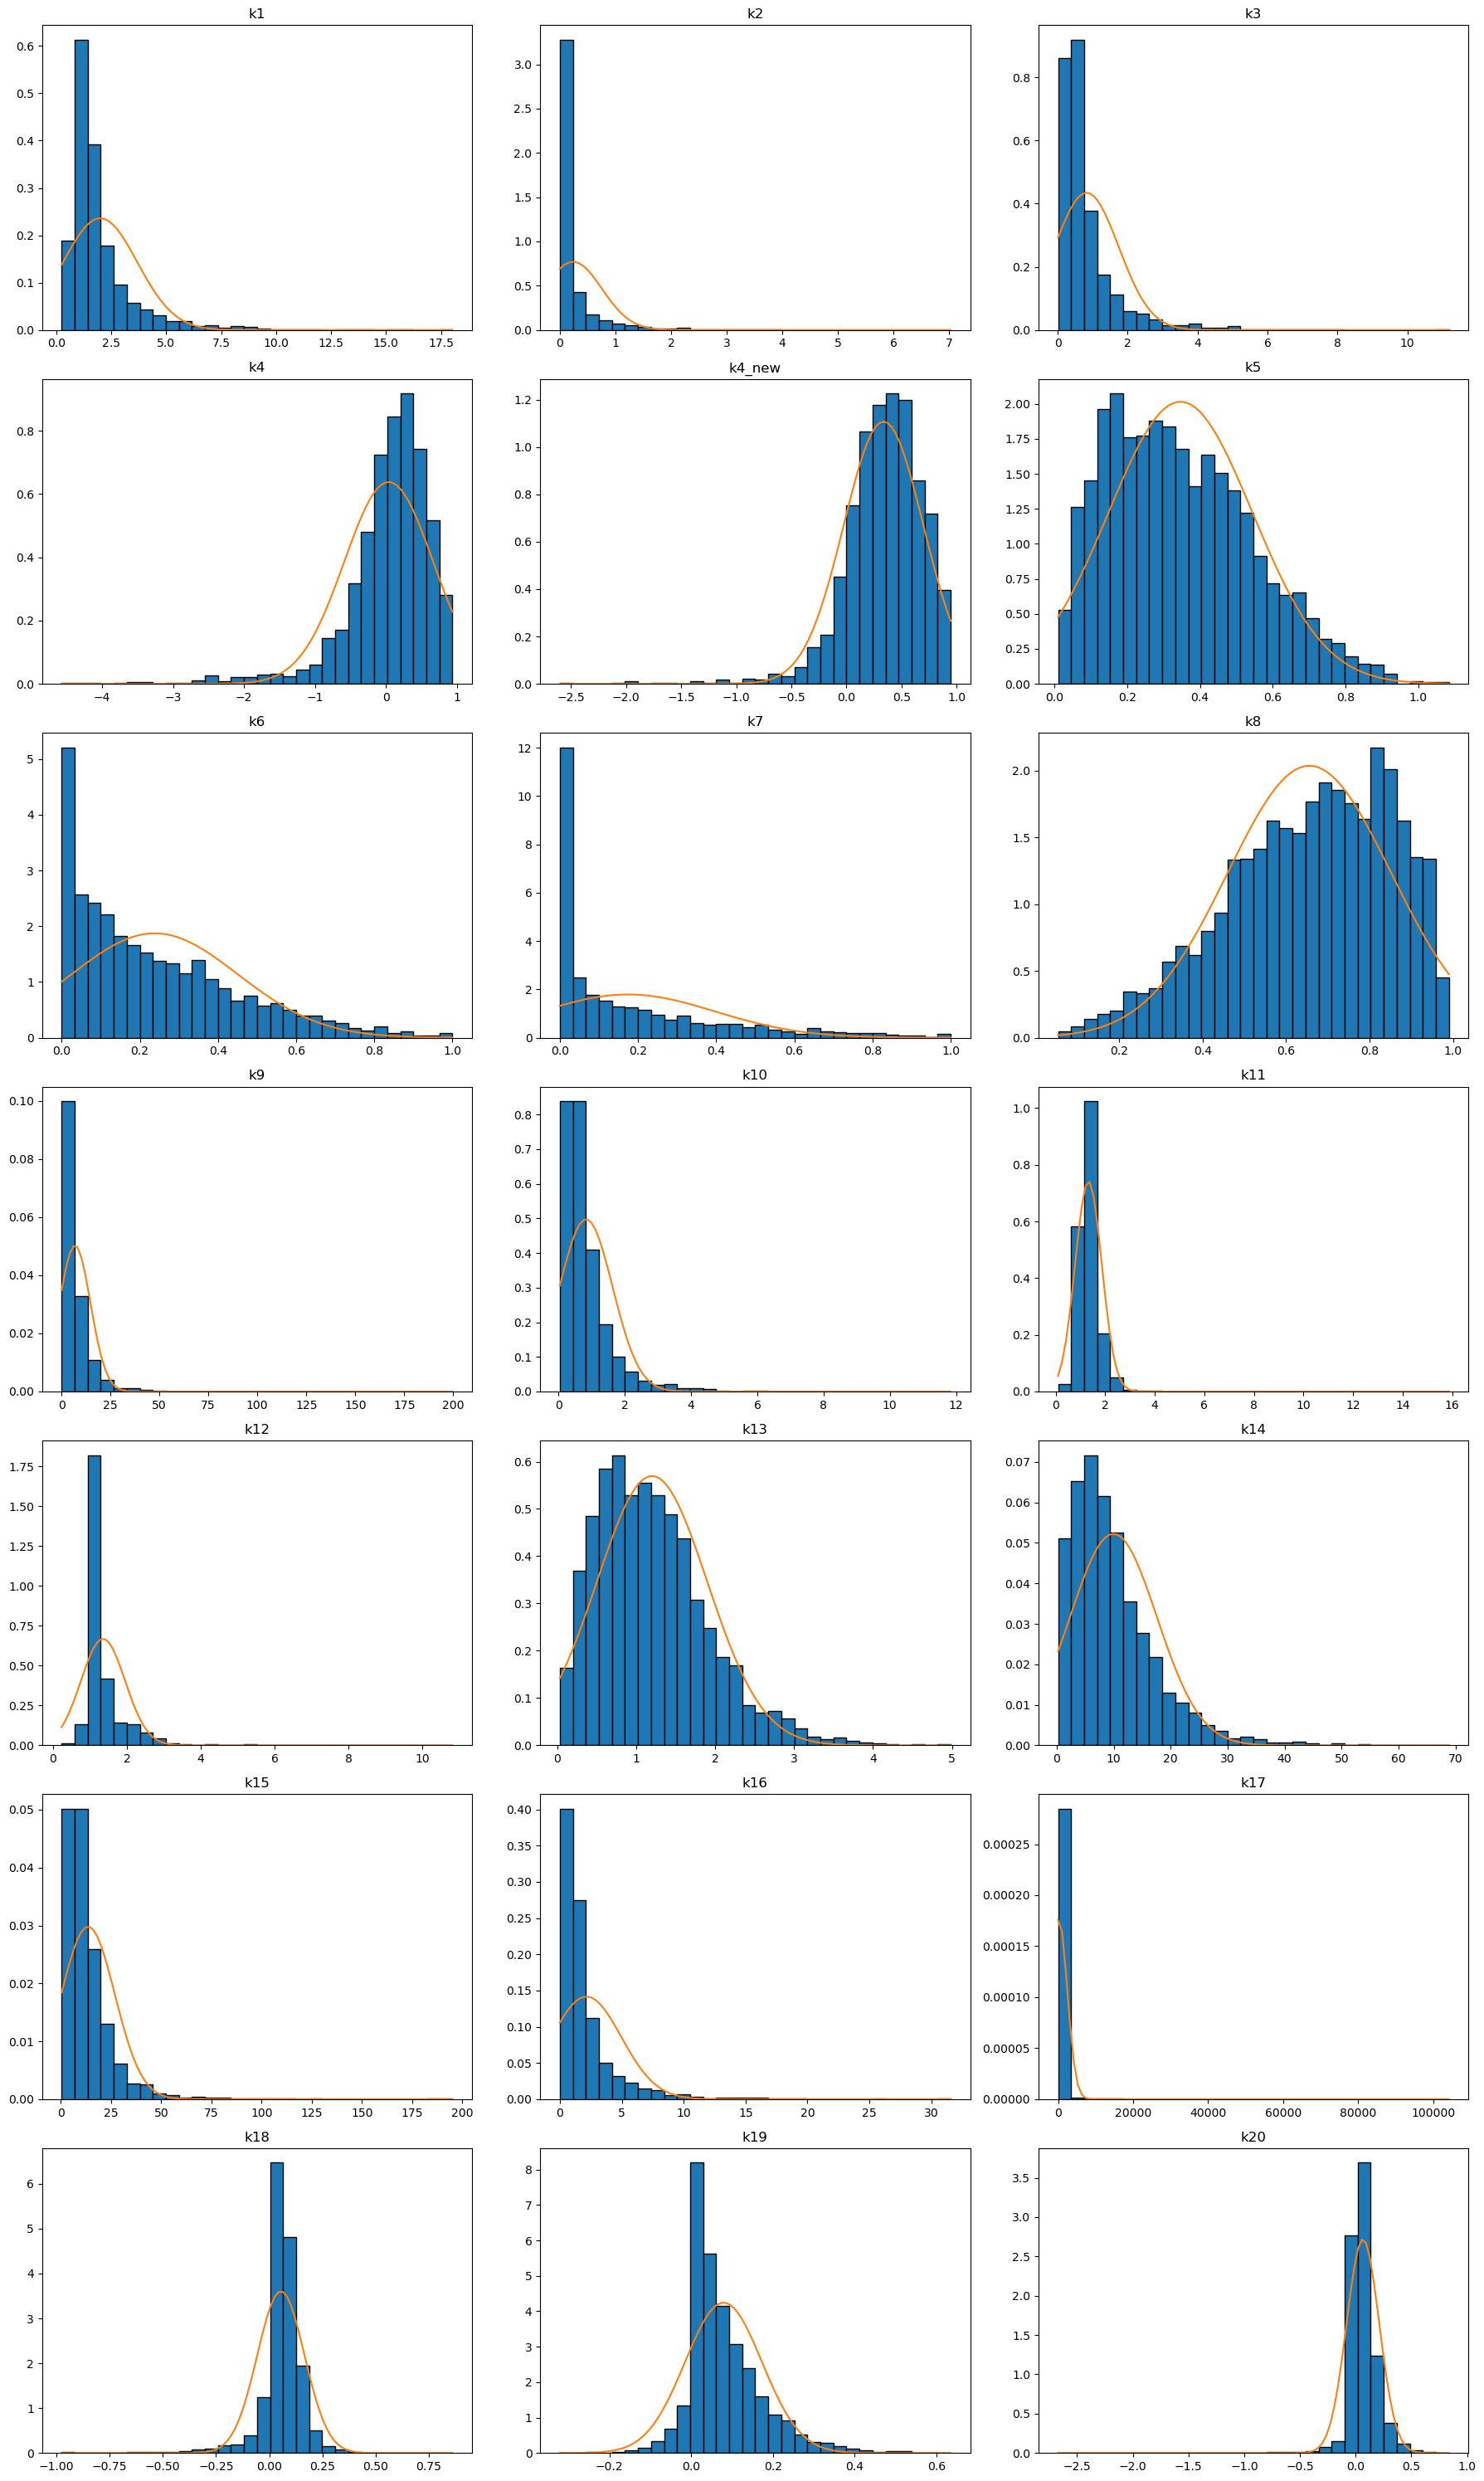

In [61]:
fig, axes = plt.subplots(7, 3, figsize = (18, 30))
axes = axes.flatten()

for i, k in enumerate(data.columns[1: -1]):
    data_tmp = data[k].dropna()
    mean_v = data_tmp.mean()
    std_v = data_tmp.std()
    
    axes[i].hist(data_tmp, bins = 30, density = True, edgecolor = 'black')
    
    x = np.linspace(data_tmp.min(), data_tmp.max(), 100)
    y = norm.pdf(x, loc = mean_v, scale = std_v)
    
    axes[i].plot(x,y)
    axes[i].set_title(k)
plt.tight_layout()
plt.show()